In [3]:
import pandas as pd

sheets = {
    'Face Wash': 'Face Wash',
    'Moisturizers': 'Moisturizers',
    'Kajal': 'Kajal & Eyeliner',
    'Shampoo': 'Shampoo',
    'Lip Care': 'Lip Care'
}

all_data = []
for name, sheet in sheets.items():
    df = pd.read_excel(r'C:\Users\arsma\Desktop\analytics\nykaa_fixed.xlsx',
                       sheet_name=sheet,
                       header=1)
    df['Category'] = name
    all_data.append(df)

combined = pd.concat(all_data, ignore_index=True)

combined['Blinkit_Available'] = combined.iloc[:, 9].astype(str).str.contains('Yes', case=False, na=False)
combined['Zepto_Available'] = combined.iloc[:, 15].astype(str).str.contains('Yes', case=False, na=False)

availability = combined.groupby('Category').agg(
    Total_Products=('Blinkit_Available', 'count'),
    Blinkit_Available=('Blinkit_Available', 'sum'),
    Zepto_Available=('Zepto_Available', 'sum')
).reset_index()

availability['Blinkit_pct'] = (availability['Blinkit_Available'] / availability['Total_Products'] * 100).round(1)
availability['Zepto_pct'] = (availability['Zepto_Available'] / availability['Total_Products'] * 100).round(1)

print(availability)

       Category  Total_Products  Blinkit_Available  Zepto_Available  \
0     Face Wash              11                  6                8   
1         Kajal              13                  4                3   
2      Lip Care              13                  4                5   
3  Moisturizers              13                  8                8   
4       Shampoo              13                  6                7   

   Blinkit_pct  Zepto_pct  
0         54.5       72.7  
1         30.8       23.1  
2         30.8       38.5  
3         61.5       61.5  
4         46.2       53.8  


In [4]:
# Check what's actually being loaded
for name, sheet in sheets.items():
    df = pd.read_excel(r"C:\Users\arsma\Desktop\analytics\nykaa_fixed.xlsx",
                       sheet_name=sheet,
                       header=1)
    print(f'\n=== {name} ===')
    print(df.shape)
    print(df.iloc[:, 0].tolist())  # Print first column to see all rows


=== Face Wash ===
(11, 22)
['Product Name', '#1  Cetaphil Gentle Skin Cleanser', '#2  Garnier Skin Naturals Micellar Oil-Infused Cleansing Water', '#3  Simple Kind to Skin Refreshing Facial Wash', '#4  Minimalist 2% Salicylic Acid + LHA Face Cleanser', '#5  Cetaphil Oily Skin Cleanser', '#6  Dot & Key Barrier Repair + Hydrating Gentle Face Wash', '#7  The Face Shop Rice Water Bright Foaming Cleanser', '#8  CeraVe Hydrating Cleanser Non-Foaming', '#9  The Derma Co 2% Salicylic Acid Anti-Acne Face Wash', '#10  CeraVe Foaming Cleanser for Oily Skin']

=== Moisturizers ===
(13, 22)
['Product Name', "#1  Pond's Super Light Gel Oil-Free Moisturiser with Hyaluronic Acid", '#2  Cetaphil Moisturising Cream', '#3  Neutrogena Hydro Boost Hyaluronic Acid Water Gel Moisturizer', '#4  Lakme Absolute Perfect Radiance Skin Brightening Day Creme', '#5  Dot & Key Hyaluronic + Ceramide Barrier Repair Hydrating Moisturizer', '#6  Dot & Key Vitamin C + E Super Bright Face Moisturizer', '#7  Clinique Moist

In [5]:
import pandas as pd

sheets = {
    'Face Wash': 'Face Wash',
    'Moisturizers': 'Moisturizers',
    'Kajal': 'Kajal & Eyeliner',
    'Shampoo': 'Shampoo',
    'Lip Care': 'Lip Care'
}

all_data = []
for name, sheet in sheets.items():
    df = pd.read_excel(r'C:\Users\arsma\Desktop\analytics\nykaa_fixed.xlsx',
                       sheet_name=sheet,
                       header=1)
    # Keep only rows where first column starts with #
    df = df[df.iloc[:, 0].astype(str).str.startswith('#')]
    df['Category'] = name
    all_data.append(df)

combined = pd.concat(all_data, ignore_index=True)

combined['Blinkit_Available'] = combined.iloc[:, 9].astype(str).str.contains('Yes', case=False, na=False)
combined['Zepto_Available'] = combined.iloc[:, 15].astype(str).str.contains('Yes', case=False, na=False)

availability = combined.groupby('Category').agg(
    Total_Products=('Blinkit_Available', 'count'),
    Blinkit_Available=('Blinkit_Available', 'sum'),
    Zepto_Available=('Zepto_Available', 'sum')
).reset_index()

availability['Blinkit_pct'] = (availability['Blinkit_Available'] / availability['Total_Products'] * 100).round(1)
availability['Zepto_pct'] = (availability['Zepto_Available'] / availability['Total_Products'] * 100).round(1)

print(availability)
print(f'\nTotal products loaded: {len(combined)}')

       Category  Total_Products  Blinkit_Available  Zepto_Available  \
0     Face Wash              10                  6                8   
1         Kajal              10                  4                3   
2      Lip Care              10                  4                5   
3  Moisturizers              10                  8                8   
4       Shampoo              10                  6                7   

   Blinkit_pct  Zepto_pct  
0         60.0       80.0  
1         40.0       30.0  
2         40.0       50.0  
3         80.0       80.0  
4         60.0       70.0  

Total products loaded: 50


In [6]:
# Get consideration column
combined['Consideration'] = combined.iloc[:, -1].astype(str)

# Cross consideration with availability
vuln = combined.groupby(['Category', 'Consideration']).agg(
    Products=('Blinkit_Available', 'count'),
    Blinkit_Available=('Blinkit_Available', 'sum'),
    Zepto_Available=('Zepto_Available', 'sum')
).reset_index()

print(vuln)

       Category Consideration  Products  Blinkit_Available  Zepto_Available
0     Face Wash         False         2                  1                0
1     Face Wash          True         8                  5                8
2         Kajal         False         7                  1                0
3         Kajal          True         3                  3                3
4      Lip Care         False         5                  0                0
5      Lip Care          True         5                  4                5
6  Moisturizers         False         2                  0                0
7  Moisturizers          True         8                  8                8
8       Shampoo         False         3                  1                0
9       Shampoo          True         7                  5                7


In [7]:
print(combined.columns.tolist())
print(combined.iloc[:5, -3:])

['PRODUCT INFO', 'Unnamed: 1', 'Unnamed: 2', 'NYKAA', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'BLINKIT', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'ZEPTO', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'ANALYSIS', 'Unnamed: 21', 'Category', 'Blinkit_Available', 'Zepto_Available', 'Consideration']
   Blinkit_Available  Zepto_Available Consideration
0               True             True          True
1              False             True          True
2              False             True          True
3               True             True          True
4               True             True          True


In [8]:
import pandas as pd

sheets = {
    'Face Wash': 'Face Wash',
    'Moisturizers': 'Moisturizers',
    'Kajal': 'Kajal & Eyeliner',
    'Shampoo': 'Shampoo',
    'Lip Care': 'Lip Care'
}

all_data = []
for name, sheet in sheets.items():
    df = pd.read_excel(r'C:\Users\arsma\Desktop\analytics\nykaa_fixed.xlsx',
                       sheet_name=sheet,
                       header=2)  # Changed to header=2
    df = df[df.iloc[:, 0].astype(str).str.startswith('#')]
    df['Category'] = name
    all_data.append(df)

combined = pd.concat(all_data, ignore_index=True)

# Check what columns look like now
print(combined.columns.tolist())
print(combined.shape)
print(combined.iloc[:2, -3:])

['Product Name', 'Brand', 'Category', 'Nykaa\nSize (ml)', 'Nykaa\nMRP (₹)', 'Nykaa\nPrice (₹)', 'Nykaa\nDisc %', 'Nykaa\n₹ / ml', 'Nykaa Rating\n(Reviews)', 'Blinkit\nAvailable', 'Blinkit\nSize (ml)', 'Blinkit\nMRP (₹)', 'Blinkit\nPrice (₹)', 'Blinkit\nDisc %', 'Blinkit\n₹ / ml', 'Zepto\nAvailable', 'Zepto\nSize (ml)', 'Zepto\nMRP (₹)', 'Zepto\nPrice (₹)', 'Zepto\nDisc %', 'Best Price\nPlatform', 'Purchase\nConsideration', 'Nykaa\nSize (g)', 'Nykaa\n₹ / g', 'Blinkit\nSize (g)', 'Blinkit\n₹ / g', 'Zepto\nSize (g)']
(50, 27)
   Blinkit\nSize (g) Blinkit\n₹ / g  Zepto\nSize (g)
0                NaN            NaN              NaN
1                NaN            NaN              NaN


In [9]:
combined['Blinkit_Available'] = combined['Blinkit\nAvailable'].astype(str).str.contains('Yes', case=False, na=False)
combined['Zepto_Available'] = combined['Zepto\nAvailable'].astype(str).str.contains('Yes', case=False, na=False)
combined['Consideration'] = combined['Purchase\nConsideration'].astype(str).str.strip()

# Verify
print(combined['Consideration'].unique())
print(combined['Blinkit_Available'].value_counts())
print(combined['Zepto_Available'].value_counts())

['Low' 'High']
Blinkit_Available
True     28
False    22
Name: count, dtype: int64
Zepto_Available
True     31
False    19
Name: count, dtype: int64


In [10]:
combined['Blinkit_Available'] = combined['Blinkit\nAvailable'].astype(str).str.contains('Yes', case=False, na=False)
combined['Zepto_Available'] = combined['Zepto\nAvailable'].astype(str).str.contains('Yes', case=False, na=False)
combined['Consideration'] = combined['Purchase\nConsideration'].astype(str).str.strip()

# Vulnerability weighted by review count
combined['Review_Count'] = combined['Nykaa Rating\n(Reviews)'].astype(str).str.extract(r'([\d,]+)(?=\))').iloc[:, 0].str.replace(',', '').astype(float)

weighted = combined[combined['Consideration'] == 'Low'].groupby(['Category', 'Blinkit_Available']).agg(
    Total_Reviews=('Review_Count', 'sum')
).reset_index()

print(weighted)

       Category  Blinkit_Available  Total_Reviews
0     Face Wash              False       540091.0
1     Face Wash               True       654452.0
2         Kajal              False       202820.0
3         Kajal               True       704274.0
4      Lip Care              False       226808.0
5      Lip Care               True       154877.0
6  Moisturizers               True      1156172.0
7       Shampoo              False         6257.0
8       Shampoo               True       592510.0


In [11]:
# Cross consideration with availability
vuln = combined.groupby(['Category', 'Consideration']).agg(
    Products=('Blinkit_Available', 'count'),
    Blinkit_Available=('Blinkit_Available', 'sum'),
    Zepto_Available=('Zepto_Available', 'sum')
).reset_index()

print(vuln)

# Most important table - Low consideration products on quick commerce
print('\n--- LOW CONSIDERATION PRODUCTS ON QUICK COMMERCE ---')
low = combined[combined['Consideration'] == 'Low'].groupby('Category').agg(
    Low_Products=('Consideration', 'count'),
    On_Blinkit=('Blinkit_Available', 'sum'),
    On_Zepto=('Zepto_Available', 'sum')
).reset_index()

low['Blinkit_Vuln_%'] = (low['On_Blinkit'] / low['Low_Products'] * 100).round(1)
low['Zepto_Vuln_%'] = (low['On_Zepto'] / low['Low_Products'] * 100).round(1)

print(low)

       Category Consideration  Products  Blinkit_Available  Zepto_Available
0     Face Wash          High         1                  1                0
1     Face Wash           Low         9                  5                8
2         Kajal          High         6                  2                1
3         Kajal           Low         4                  2                2
4      Lip Care          High         2                  0                0
5      Lip Care           Low         8                  4                5
6  Moisturizers          High         4                  2                2
7  Moisturizers           Low         6                  6                6
8       Shampoo          High         6                  3                3
9       Shampoo           Low         4                  3                4

--- LOW CONSIDERATION PRODUCTS ON QUICK COMMERCE ---
       Category  Low_Products  On_Blinkit  On_Zepto  Blinkit_Vuln_%  \
0     Face Wash             9          

In [12]:
# Extract review count as numeric
combined['Review_Count'] = combined['Nykaa Rating\n(Reviews)'].astype(str).str.extract(r'([\d,]+)(?=\))').iloc[:, 0].str.replace(',', '').astype(float)

# Vulnerability weighted by review count
weighted = combined[combined['Consideration'] == 'Low'].groupby(['Category', 'Blinkit_Available']).agg(
    Total_Reviews=('Review_Count', 'sum')
).reset_index()

print(weighted)


       Category  Blinkit_Available  Total_Reviews
0     Face Wash              False       540091.0
1     Face Wash               True       654452.0
2         Kajal              False       202820.0
3         Kajal               True       704274.0
4      Lip Care              False       226808.0
5      Lip Care               True       154877.0
6  Moisturizers               True      1156172.0
7       Shampoo              False         6257.0
8       Shampoo               True       592510.0


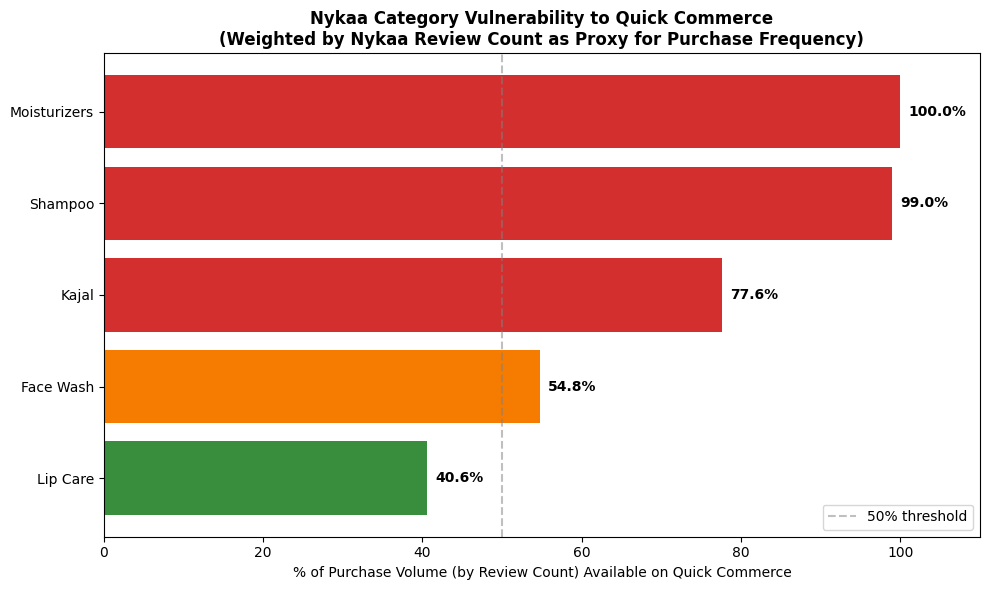

Chart saved


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Build vulnerability summary
vuln_summary = pd.DataFrame({
    'Category': ['Face Wash', 'Kajal', 'Lip Care', 'Moisturizers', 'Shampoo'],
    'Reviews_Exposed': [654452, 704274, 154877, 1156172, 592510],
    'Reviews_Protected': [540091, 202820, 226808, 0, 6257]
})

vuln_summary['Total_Reviews'] = vuln_summary['Reviews_Exposed'] + vuln_summary['Reviews_Protected']
vuln_summary['Exposure_%'] = (vuln_summary['Reviews_Exposed'] / vuln_summary['Total_Reviews'] * 100).round(1)
vuln_summary = vuln_summary.sort_values('Exposure_%', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(vuln_summary['Category'], vuln_summary['Exposure_%'],
               color=['#d32f2f' if x >= 70 else '#f57c00' if x >= 50 else '#388e3c'
                      for x in vuln_summary['Exposure_%']])

ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')

for bar, val in zip(bars, vuln_summary['Exposure_%']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')

ax.set_xlabel('% of Purchase Volume (by Review Count) Available on Quick Commerce')
ax.set_title('Nykaa Category Vulnerability to Quick Commerce\n(Weighted by Nykaa Review Count as Proxy for Purchase Frequency)', 
             fontweight='bold')
ax.set_xlim(0, 110)
ax.legend()

plt.tight_layout()
plt.savefig('vulnerability_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')


In [14]:
print(vuln_summary[['Category', 'Reviews_Exposed', 'Reviews_Protected', 'Total_Reviews', 'Exposure_%']])

       Category  Reviews_Exposed  Reviews_Protected  Total_Reviews  Exposure_%
2      Lip Care           154877             226808         381685        40.6
0     Face Wash           654452             540091        1194543        54.8
1         Kajal           704274             202820         907094        77.6
4       Shampoo           592510               6257         598767        99.0
3  Moisturizers          1156172                  0        1156172       100.0


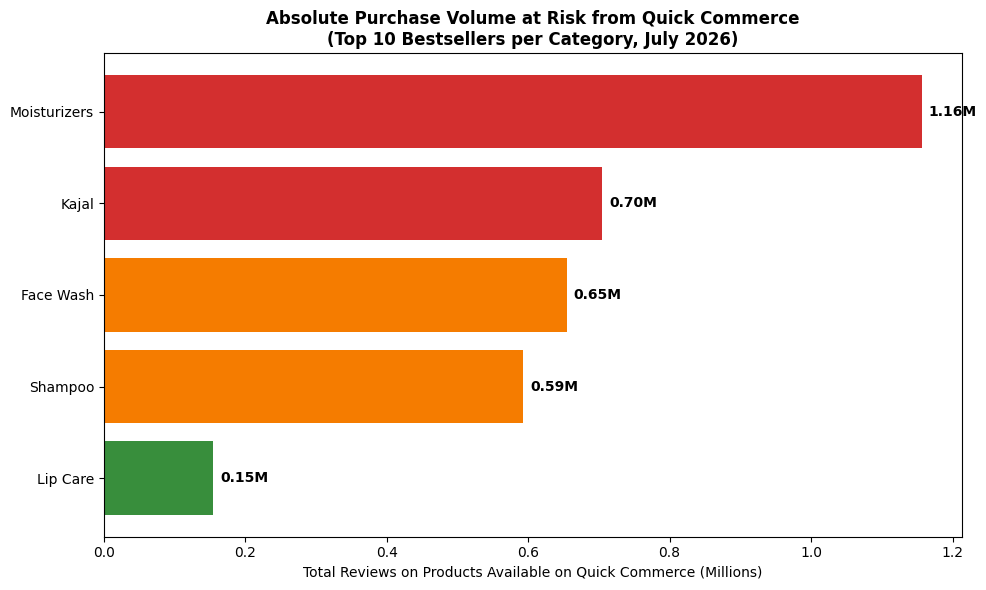

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

vuln_sorted = vuln_summary.sort_values('Reviews_Exposed', ascending=True)

bars = ax.barh(vuln_sorted['Category'], 
               vuln_sorted['Reviews_Exposed'] / 1000000,
               color=['#d32f2f' if x >= 700000 else '#f57c00' if x >= 400000 else '#388e3c'
                      for x in vuln_sorted['Reviews_Exposed']])

for bar, val in zip(bars, vuln_sorted['Reviews_Exposed']):
    ax.text(bar.get_width() + 0.01, 
            bar.get_y() + bar.get_height()/2,
            f'{val/1000000:.2f}M', va='center', fontweight='bold')

ax.set_xlabel('Total Reviews on Products Available on Quick Commerce (Millions)')
ax.set_title('Absolute Purchase Volume at Risk from Quick Commerce\n(Top 10 Bestsellers per Category, July 2026)',
             fontweight='bold')

plt.tight_layout()
plt.savefig('absolute_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Price comparison - Nykaa vs Blinkit per ml
combined['Nykaa_per_ml'] = pd.to_numeric(combined['Nykaa\n₹ / ml'], errors='coerce')
combined['Blinkit_per_ml'] = pd.to_numeric(combined['Blinkit\n₹ / ml'], errors='coerce')

price_compare = combined[combined['Blinkit_Available'] == True].dropna(subset=['Nykaa_per_ml', 'Blinkit_per_ml'])

price_compare['Price_Advantage'] = price_compare['Nykaa_per_ml'] - price_compare['Blinkit_per_ml']
price_compare['Nykaa_Cheaper'] = price_compare['Price_Advantage'] < 0

summary = price_compare.groupby('Category').agg(
    Products_On_Both=('Nykaa_per_ml', 'count'),
    Nykaa_Cheaper=('Nykaa_Cheaper', 'sum'),
    Avg_Nykaa_per_ml=('Nykaa_per_ml', 'mean'),
    Avg_Blinkit_per_ml=('Blinkit_per_ml', 'mean')
).reset_index()

summary['Avg_Nykaa_per_ml'] = summary['Avg_Nykaa_per_ml'].round(2)
summary['Avg_Blinkit_per_ml'] = summary['Avg_Blinkit_per_ml'].round(2)

print(summary)

       Category  Products_On_Both  Nykaa_Cheaper  Avg_Nykaa_per_ml  \
0     Face Wash                 6              0              4.39   
1  Moisturizers                 8              0              7.36   
2       Shampoo                 6              0              1.97   

   Avg_Blinkit_per_ml  
0                0.92  
1                0.87  
2                0.68  


In [17]:
# Check what columns have data for kajal and lip care
kajal_data = combined[combined['Category'] == 'Kajal'].iloc[:, 20:27]
print(kajal_data.head())

   Best Price\nPlatform Purchase\nConsideration  Nykaa\nSize (g)  \
20                Nykaa                     Low             0.35   
21                Nykaa                     Low             0.35   
22                Nykaa                     Low             0.35   
23                Nykaa                     Low             0.35   
24                Nykaa                    High             0.35   

    Nykaa\n₹ / g  Blinkit\nSize (g) Blinkit\n₹ / g  Zepto\nSize (g)  
20        851.43               0.35            0.9             0.35  
21        565.71               0.35            0.9             0.35  
22        540.00                NaN              —              NaN  
23        397.14                NaN              —              NaN  
24       1140.00                NaN              —              NaN  


In [18]:
# Use ml for Face Wash, Moisturizers, Shampoo, Lip Care
# Use g for Kajal
combined['Nykaa_per_unit'] = combined.apply(
    lambda x: pd.to_numeric(x['Nykaa\n₹ / g'], errors='coerce') 
    if x['Category'] == 'Kajal' 
    else pd.to_numeric(x['Nykaa\n₹ / ml'], errors='coerce'), axis=1)

combined['Blinkit_per_unit'] = combined.apply(
    lambda x: pd.to_numeric(x['Blinkit\n₹ / g'], errors='coerce')
    if x['Category'] == 'Kajal'
    else pd.to_numeric(x['Blinkit\n₹ / ml'], errors='coerce'), axis=1)

price_compare = combined[combined['Blinkit_Available'] == True].dropna(
    subset=['Nykaa_per_unit', 'Blinkit_per_unit'])

price_compare = price_compare[
    pd.to_numeric(price_compare['Blinkit_per_unit'], errors='coerce').notna()]

price_compare['Blinkit_per_unit'] = pd.to_numeric(
    price_compare['Blinkit_per_unit'], errors='coerce')

price_compare['Nykaa_Cheaper'] = price_compare['Nykaa_per_unit'] < price_compare['Blinkit_per_unit']

summary = price_compare.groupby('Category').agg(
    Products_On_Both=('Nykaa_per_unit', 'count'),
    Nykaa_Cheaper_Count=('Nykaa_Cheaper', 'sum'),
    Avg_Nykaa=('Nykaa_per_unit', 'mean'),
    Avg_Blinkit=('Blinkit_per_unit', 'mean')
).reset_index()

summary['Nykaa_Cheaper_%'] = (summary['Nykaa_Cheaper_Count'] / summary['Products_On_Both'] * 100).round(1)
summary['Avg_Nykaa'] = summary['Avg_Nykaa'].round(2)
summary['Avg_Blinkit'] = summary['Avg_Blinkit'].round(2)

print(summary)

       Category  Products_On_Both  Nykaa_Cheaper_Count  Avg_Nykaa  \
0     Face Wash                 6                    0       4.39   
1         Kajal                 4                    0    1068.93   
2  Moisturizers                 8                    0       7.36   
3       Shampoo                 6                    0       1.97   

   Avg_Blinkit  Nykaa_Cheaper_%  
0         0.92              0.0  
1         0.90              0.0  
2         0.87              0.0  
3         0.68              0.0  


In [19]:
lip = combined[combined['Category'] == 'Lip Care']
print(lip[['Nykaa\n₹ / ml', 'Nykaa\n₹ / g', 'Blinkit_Available']].head(10))

    Nykaa\n₹ / ml  Nykaa\n₹ / g  Blinkit_Available
40            NaN         24.89              False
41            NaN         75.00              False
42            NaN         12.55               True
43            NaN         65.53               True
44            NaN         37.92               True
45            NaN         55.11              False
46            NaN         56.00               True
47            NaN         55.11              False
48            NaN         59.25              False
49            NaN         94.44              False


In [20]:
combined['Nykaa_per_unit'] = combined.apply(
    lambda x: pd.to_numeric(x['Nykaa\n₹ / g'], errors='coerce') 
    if x['Category'] in ['Kajal', 'Lip Care'] 
    else pd.to_numeric(x['Nykaa\n₹ / ml'], errors='coerce'), axis=1)

combined['Blinkit_per_unit'] = combined.apply(
    lambda x: pd.to_numeric(x['Blinkit\n₹ / g'], errors='coerce')
    if x['Category'] in ['Kajal', 'Lip Care']
    else pd.to_numeric(x['Blinkit\n₹ / ml'], errors='coerce'), axis=1)

price_compare = combined[combined['Blinkit_Available'] == True].copy()
price_compare['Blinkit_per_unit'] = pd.to_numeric(
    price_compare['Blinkit_per_unit'], errors='coerce')
price_compare = price_compare.dropna(subset=['Nykaa_per_unit', 'Blinkit_per_unit'])

price_compare['Nykaa_Cheaper'] = price_compare['Nykaa_per_unit'] < price_compare['Blinkit_per_unit']

summary = price_compare.groupby('Category').agg(
    Products_On_Both=('Nykaa_per_unit', 'count'),
    Nykaa_Cheaper_Count=('Nykaa_Cheaper', 'sum'),
    Avg_Nykaa=('Nykaa_per_unit', 'mean'),
    Avg_Blinkit=('Blinkit_per_unit', 'mean')
).reset_index()

summary['Nykaa_Cheaper_%'] = (summary['Nykaa_Cheaper_Count'] / summary['Products_On_Both'] * 100).round(1)
summary['Avg_Nykaa'] = summary['Avg_Nykaa'].round(2)
summary['Avg_Blinkit'] = summary['Avg_Blinkit'].round(2)

print(summary)

       Category  Products_On_Both  Nykaa_Cheaper_Count  Avg_Nykaa  \
0     Face Wash                 6                    0       4.39   
1         Kajal                 4                    0    1068.93   
2      Lip Care                 4                    0      43.00   
3  Moisturizers                 8                    0       7.36   
4       Shampoo                 6                    0       1.97   

   Avg_Blinkit  Nykaa_Cheaper_%  
0         0.92              0.0  
1         0.90              0.0  
2         0.89              0.0  
3         0.87              0.0  
4         0.68              0.0  


In [21]:
combined['Review_Count'] = combined['Nykaa Rating\n(Reviews)'].astype(str).str.extract(r'([\d,]+)(?=\))').iloc[:, 0].str.replace(',', '').astype(float)

weighted = combined[combined['Consideration'] == 'Low'].groupby(['Category', 'Blinkit_Available']).agg(
    Total_Reviews=('Review_Count', 'sum')
).reset_index()

print(weighted)

       Category  Blinkit_Available  Total_Reviews
0     Face Wash              False       540091.0
1     Face Wash               True       654452.0
2         Kajal              False       202820.0
3         Kajal               True       704274.0
4      Lip Care              False       226808.0
5      Lip Care               True       154877.0
6  Moisturizers               True      1156172.0
7       Shampoo              False         6257.0
8       Shampoo               True       592510.0


In [22]:
import matplotlib.pyplot as plt

vuln_summary = pd.DataFrame({
    'Category': ['Face Wash', 'Kajal', 'Lip Care', 'Moisturizers', 'Shampoo'],
    'Reviews_Exposed': [654452, 704274, 154877, 1156172, 592510],
    'Reviews_Protected': [540091, 202820, 226808, 0, 6257]
})

vuln_summary['Total_Reviews'] = vuln_summary['Reviews_Exposed'] + vuln_summary['Reviews_Protected']
vuln_summary['Exposure_pct'] = (vuln_summary['Reviews_Exposed'] / vuln_summary['Total_Reviews'] * 100).round(1)
vuln_summary = vuln_summary.sort_values('Exposure_pct', ascending=False)

print(vuln_summary[['Category', 'Reviews_Exposed', 'Exposure_pct']].to_string(index=False))

    Category  Reviews_Exposed  Exposure_pct
Moisturizers          1156172         100.0
     Shampoo           592510          99.0
       Kajal           704274          77.6
   Face Wash           654452          54.8
    Lip Care           154877          40.6


In [23]:
# Top product concentration within exposed Low consideration products
exposed = combined[(combined['Consideration'] == 'Low') & 
                   (combined['Blinkit_Available'] == True)].copy()

exposed['Review_Count'] = exposed['Nykaa Rating\n(Reviews)'].astype(str).str.extract(
    r'([\d,]+)(?=\))').iloc[:, 0].str.replace(',', '').astype(float)

# For each category, what % of exposed reviews come from the top 1 product
def top_concentration(group):
    total = group['Review_Count'].sum()
    top1 = group['Review_Count'].max()
    return round(top1 / total * 100, 1)

concentration = exposed.groupby('Category').apply(top_concentration).reset_index()
concentration.columns = ['Category', 'Top1_Product_Concentration_%']

print(concentration.sort_values('Top1_Product_Concentration_%', ascending=False))

       Category  Top1_Product_Concentration_%
4       Shampoo                          88.8
1         Kajal                          81.2
0     Face Wash                          58.4
3  Moisturizers                          57.5
2      Lip Care                          42.6


C:\Users\arsma\AppData\Local\Temp\ipykernel_14464\1646811838.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  concentration = exposed.groupby('Category').apply(top_concentration).reset_index()


In [24]:
import matplotlib.pyplot as plt

vuln_summary = pd.DataFrame({
    'Category': ['Face Wash', 'Kajal', 'Lip Care', 'Moisturizers', 'Shampoo'],
    'Reviews_Exposed': [654452, 704274, 154877, 1156172, 592510],
    'Reviews_Protected': [540091, 202820, 226808, 0, 6257]
})

vuln_summary['Total_Reviews'] = vuln_summary['Reviews_Exposed'] + vuln_summary['Reviews_Protected']
vuln_summary['Exposure_pct'] = (vuln_summary['Reviews_Exposed'] / vuln_summary['Total_Reviews'] * 100).round(1)
vuln_summary = vuln_summary.sort_values('Exposure_pct', ascending=False)

print(vuln_summary[['Category', 'Reviews_Exposed', 'Exposure_pct']].to_string(index=False))

    Category  Reviews_Exposed  Exposure_pct
Moisturizers          1156172         100.0
     Shampoo           592510          99.0
       Kajal           704274          77.6
   Face Wash           654452          54.8
    Lip Care           154877          40.6


In [25]:
# Build final vulnerability matrix

final = vuln_summary.merge(concentration, on='Category')



# Normalize each metric to 0-100 scale

final['Vol_Score'] = (final['Reviews_Exposed'] / final['Reviews_Exposed'].max() * 100).round(1)

final['Pen_Score'] = final['Exposure_pct']

final['Con_Score'] = final['Top1_Product_Concentration_%']



# Composite: 40% volume + 35% penetration + 25% concentration

final['Vulnerability_Score'] = (

    final['Vol_Score'] * 0.40 +

    final['Pen_Score'] * 0.35 +

    final['Con_Score'] * 0.25

).round(1)



final_sorted = final[['Category', 'Reviews_Exposed', 'Exposure_pct', 

                        'Top1_Product_Concentration_%', 'Vulnerability_Score']].sort_values(

    'Vulnerability_Score', ascending=False)



print(final_sorted.to_string(index=False))



    Category  Reviews_Exposed  Exposure_pct  Top1_Product_Concentration_%  Vulnerability_Score
Moisturizers          1156172         100.0                          57.5                 89.4
     Shampoo           592510          99.0                          88.8                 77.3
       Kajal           704274          77.6                          81.2                 71.8
   Face Wash           654452          54.8                          58.4                 56.4
    Lip Care           154877          40.6                          42.6                 30.2


In [26]:
final['Vulnerability_Score_v2'] = (
    final['Vol_Score'] * 0.20 +
    final['Pen_Score'] * 0.40 +
    final['Con_Score'] * 0.35
).round(1)

print(final[['Category', 'Vulnerability_Score', 'Vulnerability_Score_v2']].sort_values(
    'Vulnerability_Score_v2', ascending=False).to_string(index=False))

    Category  Vulnerability_Score  Vulnerability_Score_v2
     Shampoo                 77.3                    80.9
Moisturizers                 89.4                    80.1
       Kajal                 71.8                    71.6
   Face Wash                 56.4                    53.7
    Lip Care                 30.2                    33.8


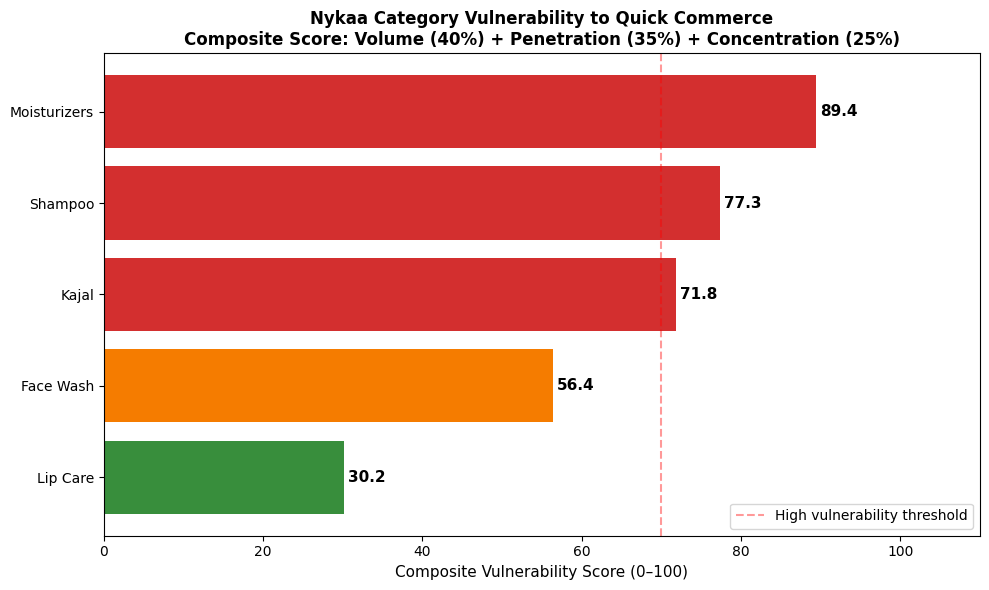

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = final_sorted.sort_values('Vulnerability_Score', ascending=True)

colors = ['#388e3c' if x < 50 else '#f57c00' if x < 70 else '#d32f2f' 
          for x in plot_data['Vulnerability_Score']]

bars = ax.barh(plot_data['Category'], plot_data['Vulnerability_Score'], color=colors)

for bar, val in zip(bars, plot_data['Vulnerability_Score']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Composite Vulnerability Score (0–100)', fontsize=11)
ax.set_title('Nykaa Category Vulnerability to Quick Commerce\nComposite Score: Volume (40%) + Penetration (35%) + Concentration (25%)',
             fontweight='bold', fontsize=12)
ax.set_xlim(0, 110)
ax.axvline(x=70, color='red', linestyle='--', alpha=0.4, label='High vulnerability threshold')
ax.legend()

plt.tight_layout()
plt.savefig('composite_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Price comparison - Nykaa vs Blinkit per unit
combined['Nykaa_per_unit'] = combined.apply(
    lambda x: pd.to_numeric(x['Nykaa\n₹ / g'], errors='coerce') 
    if x['Category'] in ['Kajal', 'Lip Care'] 
    else pd.to_numeric(x['Nykaa\n₹ / ml'], errors='coerce'), axis=1)

combined['Blinkit_per_unit'] = combined.apply(
    lambda x: pd.to_numeric(x['Blinkit\n₹ / g'], errors='coerce')
    if x['Category'] in ['Kajal', 'Lip Care']
    else pd.to_numeric(x['Blinkit\n₹ / ml'], errors='coerce'), axis=1)

price = combined[combined['Blinkit_Available'] == True].copy()
price['Blinkit_per_unit'] = pd.to_numeric(price['Blinkit_per_unit'], errors='coerce')
price = price.dropna(subset=['Nykaa_per_unit', 'Blinkit_per_unit'])

price['Nykaa_Cheaper'] = price['Nykaa_per_unit'] < price['Blinkit_per_unit']

summary = price.groupby('Category').agg(
    Products=('Nykaa_per_unit', 'count'),
    Nykaa_Cheaper=('Nykaa_Cheaper', 'sum'),
    Avg_Nykaa=('Nykaa_per_unit', 'mean'),
    Avg_Blinkit=('Blinkit_per_unit', 'mean')
).reset_index()

summary['Nykaa_Cheaper_%'] = (summary['Nykaa_Cheaper'] / summary['Products'] * 100).round(1)
summary['Avg_Nykaa'] = summary['Avg_Nykaa'].round(2)
summary['Avg_Blinkit'] = summary['Avg_Blinkit'].round(2)

print(summary)

       Category  Products  Nykaa_Cheaper  Avg_Nykaa  Avg_Blinkit  \
0     Face Wash         6              0       4.39         0.92   
1         Kajal         4              0    1068.93         0.90   
2      Lip Care         4              0      43.00         0.89   
3  Moisturizers         8              0       7.36         0.87   
4       Shampoo         6              0       1.97         0.68   

   Nykaa_Cheaper_%  
0              0.0  
1              0.0  
2              0.0  
3              0.0  
4              0.0  


In [29]:
# Check what's actually in the per-unit columns
print(combined[['Category', 'Nykaa\n₹ / ml', 'Nykaa\n₹ / g', 'Blinkit\n₹ / ml', 'Blinkit\n₹ / g']].head(20))
print("\nBlinkit available count:", combined['Blinkit_Available'].sum())

        Category  Nykaa\n₹ / ml  Nykaa\n₹ / g Blinkit\n₹ / ml Blinkit\n₹ / g
0      Face Wash           3.34           NaN            0.91            NaN
1      Face Wash           1.12           NaN               —            NaN
2      Face Wash           2.70           NaN               —            NaN
3      Face Wash           2.84           NaN            0.95            NaN
4      Face Wash           5.39           NaN            0.88            NaN
5      Face Wash           2.24           NaN               —            NaN
6      Face Wash           5.69           NaN            0.97            NaN
7      Face Wash           3.38           NaN             0.9            NaN
8      Face Wash           5.09           NaN               —            NaN
9      Face Wash           5.72           NaN             0.9            NaN
10  Moisturizers           6.78           NaN            0.75            NaN
11  Moisturizers           7.28           NaN             0.9            NaN

In [60]:
from openpyxl import load_workbook
import pandas as pd

wb = load_workbook(r'C:\Users\arsma\Desktop\analytics\nykaa_fixed.xlsx', data_only=True)

all_data = []
for sheet in ['Face Wash', 'Moisturizers', 'Kajal & Eyeliner', 'Shampoo', 'Lip Care']:
    ws = wb[sheet]
    for row in ws.iter_rows(min_row=4, max_row=13, values_only=True):
        if row[0] and str(row[0]).startswith('#'):
            all_data.append({
                'Product': row[0],
                'Sheet': sheet,
                'Nykaa_Price': row[5],      # Col F
                'Nykaa_Size_ml': row[3],     # Col D
                'Nykaa_Size_g': row[22],     # Col W
                'Blinkit_Avail': row[9],     # Col J
                'Blinkit_Price': row[12],    # Col M
                'Blinkit_Size_ml': row[10],  # Col K
                'Blinkit_Size_g': row[24],   # Col Y
            })

df = pd.DataFrame(all_data)
print(df[df['Blinkit_Avail'] == '✅ Yes'][
    ['Product', 'Sheet', 'Nykaa_Price', 'Nykaa_Size_ml', 
     'Blinkit_Price', 'Blinkit_Size_ml', 'Blinkit_Size_g']].to_string())

IndexError: tuple index out of range

In [62]:
from openpyxl import load_workbook

wb = load_workbook(r'C:\Users\arsma\Desktop\analytics\nykaa_fixed.xlsx', data_only=True)
ws = wb['Face Wash']

# Print all columns in row 3 (header row)
for i, cell in enumerate(ws[3]):
    print(f"Index {i} | Col {cell.column_letter} | Value: {cell.value}")

Index 0 | Col A | Value: Product Name
Index 1 | Col B | Value: Brand
Index 2 | Col C | Value: Category
Index 3 | Col D | Value: Nykaa
Size (ml)
Index 4 | Col E | Value: Nykaa
MRP (₹)
Index 5 | Col F | Value: Nykaa
Price (₹)
Index 6 | Col G | Value: Nykaa
Disc %
Index 7 | Col H | Value: Nykaa
₹ / ml
Index 8 | Col I | Value: Nykaa Rating
(Reviews)
Index 9 | Col J | Value: Blinkit
Available
Index 10 | Col K | Value: Blinkit
Size (ml)
Index 11 | Col L | Value: Blinkit
MRP (₹)
Index 12 | Col M | Value: Blinkit
Price (₹)
Index 13 | Col N | Value: Blinkit
Disc %
Index 14 | Col O | Value: Blinkit
₹ / ml
Index 15 | Col P | Value: Zepto
Available
Index 16 | Col Q | Value: Zepto
Size (ml)
Index 17 | Col R | Value: Zepto
MRP (₹)
Index 18 | Col S | Value: Zepto
Price (₹)
Index 19 | Col T | Value: Zepto
Disc %
Index 20 | Col U | Value: Best Price
Platform
Index 21 | Col V | Value: Purchase
Consideration


In [64]:
from openpyxl import load_workbook
import pandas as pd

wb = load_workbook(r'C:\Users\arsma\Desktop\analytics\nykaa_fixed.xlsx', data_only=True)

all_data = []
for sheet in ['Face Wash', 'Moisturizers', 'Kajal & Eyeliner', 'Shampoo', 'Lip Care']:
    ws = wb[sheet]
    # Get max column count for this sheet
    max_col = ws.max_column
    
    for row in ws.iter_rows(min_row=4, max_row=13, values_only=True):
        if row[0] and str(row[0]).startswith('#'):
            row_dict = {
                'Product': row[0],
                'Sheet': sheet,
                'Nykaa_Price': row[5],
                'Nykaa_Size_ml': row[3],
                'Blinkit_Avail': row[9],
                'Blinkit_Price': row[12],
                'Blinkit_Size_ml': row[10],
            }
            # g columns only exist in some sheets
            row_dict['Nykaa_Size_g'] = row[22] if max_col > 22 else None
            row_dict['Blinkit_Size_g'] = row[24] if max_col > 24 else None
            all_data.append(row_dict)

df = pd.DataFrame(all_data)
print(df[df['Blinkit_Avail'] == '✅ Yes'][
    ['Product', 'Sheet', 'Nykaa_Price', 'Nykaa_Size_ml',
     'Blinkit_Price', 'Blinkit_Size_ml', 'Nykaa_Size_g', 'Blinkit_Size_g']
].to_string())

                                                                        Product             Sheet  Nykaa_Price  Nykaa_Size_ml  Blinkit_Price  Blinkit_Size_ml Nykaa_Size_g Blinkit_Size_g
0                                             #1  Cetaphil Gentle Skin Cleanser         Face Wash          418         125.00          418.0           118.00         None           None
3                          #4  Minimalist 2% Salicylic Acid + LHA Face Cleanser         Face Wash          284         100.00          285.0           100.00         None           None
4                                               #5  Cetaphil Oily Skin Cleanser         Face Wash          674         125.00          660.0           118.00         None           None
6                          #7  The Face Shop Rice Water Bright Foaming Cleanser         Face Wash          854         150.00          607.0           100.00         None           None
7                                     #8  CeraVe Hydrating Cleanser No

In [66]:
# Calculate per unit from raw price and size
df['Nykaa_per_unit'] = df['Nykaa_Price'] / df['Nykaa_Size_ml']
df['Blinkit_per_unit'] = df['Blinkit_Price'] / df['Blinkit_Size_ml']

df['Nykaa_per_unit'] = df['Nykaa_per_unit'].round(2)
df['Blinkit_per_unit'] = df['Blinkit_per_unit'].round(2)

df['Nykaa_Cheaper'] = df['Nykaa_per_unit'] < df['Blinkit_per_unit']
df['Category'] = df['Sheet'].replace({'Kajal & Eyeliner': 'Kajal'})

summary = df.groupby('Category').agg(
    Products=('Nykaa_per_unit', 'count'),
    Nykaa_Cheaper=('Nykaa_Cheaper', 'sum'),
    Avg_Nykaa=('Nykaa_per_unit', 'mean'),
    Avg_Blinkit=('Blinkit_per_unit', 'mean')
).reset_index()

summary['Nykaa_Cheaper_%'] = (summary['Nykaa_Cheaper'] / summary['Products'] * 100).round(1)
summary['Avg_Nykaa'] = summary['Avg_Nykaa'].round(2)
summary['Avg_Blinkit'] = summary['Avg_Blinkit'].round(2)

print(summary)

       Category  Products  Nykaa_Cheaper  Avg_Nykaa  Avg_Blinkit  \
0     Face Wash        10              4       3.75         4.52   
1         Kajal        10              2    1070.12      1136.43   
2      Lip Care        10              1      53.58        44.06   
3  Moisturizers        10              3       9.78         8.22   
4       Shampoo        10              1       3.18         1.99   

   Nykaa_Cheaper_%  
0             40.0  
1             20.0  
2             10.0  
3             30.0  
4             10.0  


In [68]:
from openpyxl import load_workbook
import pandas as pd
import matplotlib.pyplot as plt

wb = load_workbook(r'C:\Users\arsma\Desktop\analytics\nykaa_fixed.xlsx', data_only=True)

all_data = []
for sheet in ['Face Wash', 'Moisturizers', 'Kajal & Eyeliner', 'Shampoo', 'Lip Care']:
    ws = wb[sheet]
    for row in ws.iter_rows(min_row=4, max_row=13, values_only=True):
        if row[0] and str(row[0]).startswith('#'):
            all_data.append({
                'Product': str(row[0]),
                'Category': sheet,
                'Nykaa_Price': row[5],
                'Nykaa_Size': row[3],
                'Blinkit_Avail': str(row[9]),
                'Blinkit_Price': row[12],
                'Blinkit_Size': row[10],
            })

df = pd.DataFrame(all_data)

# Keep only products on Blinkit with valid prices and sizes
df = df[df['Blinkit_Avail'] == '✅ Yes'].copy()
df['Nykaa_Price'] = pd.to_numeric(df['Nykaa_Price'], errors='coerce')
df['Nykaa_Size'] = pd.to_numeric(df['Nykaa_Size'], errors='coerce')
df['Blinkit_Price'] = pd.to_numeric(df['Blinkit_Price'], errors='coerce')
df['Blinkit_Size'] = pd.to_numeric(df['Blinkit_Size'], errors='coerce')
df = df.dropna(subset=['Nykaa_Price', 'Nykaa_Size', 'Blinkit_Price', 'Blinkit_Size'])
df = df[df['Nykaa_Size'] > 0]
df = df[df['Blinkit_Size'] > 0]

# Calculate per unit
df['Nykaa_per_unit'] = (df['Nykaa_Price'] / df['Nykaa_Size']).round(2)
df['Blinkit_per_unit'] = (df['Blinkit_Price'] / df['Blinkit_Size']).round(2)
df['Nykaa_Cheaper'] = df['Nykaa_per_unit'] < df['Blinkit_per_unit']
df['Category'] = df['Category'].replace({'Kajal & Eyeliner': 'Kajal'})

# Summary per category
summary = df.groupby('Category').agg(
    Products=('Nykaa_per_unit', 'count'),
    Nykaa_Cheaper=('Nykaa_Cheaper', 'sum'),
    Avg_Nykaa=('Nykaa_per_unit', 'mean'),
    Avg_Blinkit=('Blinkit_per_unit', 'mean')
).reset_index()

summary['Nykaa_Cheaper_%'] = (summary['Nykaa_Cheaper'] / summary['Products'] * 100).round(1)
summary['Avg_Nykaa'] = summary['Avg_Nykaa'].round(2)
summary['Avg_Blinkit'] = summary['Avg_Blinkit'].round(2)
summary['Price_Advantage'] = summary['Avg_Nykaa'] - summary['Avg_Blinkit']

print(summary)
print(f"\nTotal products compared: {len(df)}")
print(f"\nProduct-level breakdown:")
print(df[['Product', 'Category', 'Nykaa_per_unit', 'Blinkit_per_unit', 'Nykaa_Cheaper']].to_string())

       Category  Products  Nykaa_Cheaper  Avg_Nykaa  Avg_Blinkit  \
0     Face Wash         6              4       4.39         4.52   
1         Kajal         4              2    1068.93      1136.43   
2      Lip Care         4              1      43.00        44.06   
3  Moisturizers         8              3       7.35         8.22   
4       Shampoo         6              1       1.97         1.99   

   Nykaa_Cheaper_%  Price_Advantage  
0             66.7            -0.13  
1             50.0           -67.50  
2             25.0            -1.06  
3             37.5            -0.87  
4             16.7            -0.02  

Total products compared: 28

Product-level breakdown:
                                                                        Product      Category  Nykaa_per_unit  Blinkit_per_unit  Nykaa_Cheaper
0                                             #1  Cetaphil Gentle Skin Cleanser     Face Wash            3.34              3.54           True
3                     

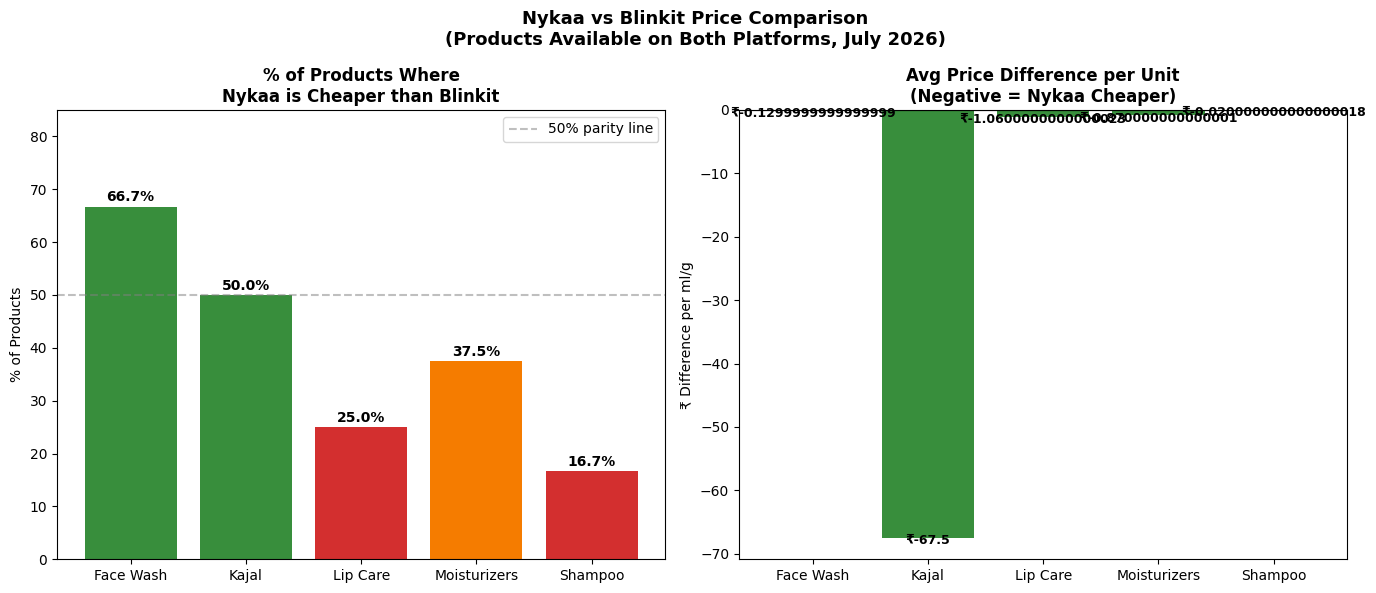

In [70]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

categories = summary['Category']
x = np.arange(len(categories))

# Chart 1 - % products where Nykaa is cheaper
colors = ['#388e3c' if v >= 50 else '#f57c00' if v >= 30 else '#d32f2f' 
          for v in summary['Nykaa_Cheaper_%']]
bars = ax1.bar(categories, summary['Nykaa_Cheaper_%'], color=colors)
ax1.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% parity line')
for bar, val in zip(bars, summary['Nykaa_Cheaper_%']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}%', ha='center', fontweight='bold')
ax1.set_title('% of Products Where\nNykaa is Cheaper than Blinkit', fontweight='bold')
ax1.set_ylabel('% of Products')
ax1.set_ylim(0, 85)
ax1.legend()

# Chart 2 - Average price advantage/disadvantage
price_adv = summary['Price_Advantage']
colors2 = ['#388e3c' if v < 0 else '#d32f2f' for v in price_adv]
bars2 = ax2.bar(categories, price_adv, color=colors2)
ax2.axhline(y=0, color='black', linewidth=0.8)
for bar, val in zip(bars2, price_adv):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val - 1 if val < 0 else val + 0.5,
             f'₹{val}', ha='center', fontweight='bold', fontsize=9)
ax2.set_title('Avg Price Difference per Unit\n(Negative = Nykaa Cheaper)', fontweight='bold')
ax2.set_ylabel('₹ Difference per ml/g')

plt.suptitle('Nykaa vs Blinkit Price Comparison\n(Products Available on Both Platforms, July 2026)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('price_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

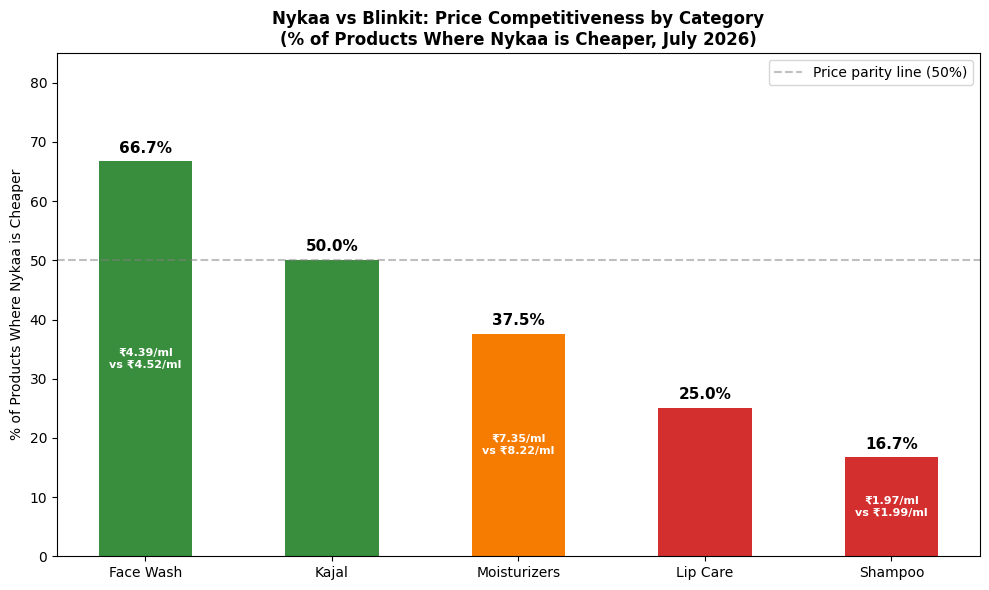

In [74]:
fig, ax = plt.subplots(figsize=(10, 6))

summary_sorted = summary.sort_values('Nykaa_Cheaper_%', ascending=False)

colors = ['#388e3c' if v >= 50 else '#f57c00' if v >= 30 else '#d32f2f'
          for v in summary_sorted['Nykaa_Cheaper_%']]

bars = ax.bar(summary_sorted['Category'], 
              summary_sorted['Nykaa_Cheaper_%'], 
              color=colors, width=0.5)

ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Price parity line (50%)')

for bar, (_, row) in zip(bars, summary_sorted.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{row['Nykaa_Cheaper_%']}%", ha='center', fontweight='bold', fontsize=11)
    # Only show avg prices for ml-based categories
    if row['Category'] not in ['Kajal', 'Lip Care']:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f"₹{row['Avg_Nykaa']:.2f}/ml\nvs ₹{row['Avg_Blinkit']:.2f}/ml",
                ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax.set_title('Nykaa vs Blinkit: Price Competitiveness by Category\n(% of Products Where Nykaa is Cheaper, July 2026)',
             fontweight='bold', fontsize=12)
ax.set_ylabel('% of Products Where Nykaa is Cheaper', fontsize=10)
ax.set_ylim(0, 85)
ax.legend()

plt.tight_layout()
plt.savefig('price_comparison.png', dpi=150, bbox_inches='tight')
plt.show()